In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# ----------------------------------------------------
# 1. Import the datasets
# ----------------------------------------------------
covid_data = pd.read_csv("D:/Sx Varun/Sx Code/MCA/2nd_Tri/python/dataSet/covid_data.csv")
covid = pd.read_csv("D:/Sx Varun/Sx Code/MCA/2nd_Tri/python/dataSet/covid.csv")

# Check top rows
print("covid_data.csv:")
print(covid_data.head())
print("\ncovid.csv:")
print(covid.head())

covid_data.csv:
   Unnamed: 0        date                       region  confirmed  active  \
0           0  27-03-2020  Andaman and Nicobar Islands          1       1   
1           1  28-03-2020  Andaman and Nicobar Islands          6       6   
2           2  29-03-2020  Andaman and Nicobar Islands          9       9   
3           3  30-03-2020  Andaman and Nicobar Islands          9       9   
4           4  31-03-2020  Andaman and Nicobar Islands         10      10   

   cured  deaths  
0      0       0  
1      0       0  
2      0       0  
3      0       0  
4      0       0  

covid.csv:
                 state  confirmed  active  passive  deaths     dose1  \
0  Andaman and Nicobar      10742       1    10612     129    313284   
1       Andhra Pradesh    2339067       3  2324331   14733  40643161   
2    Arunachal Pradesh      66890       0    66594     296    860442   
3                Assam     746100       0   738065    8035  22549957   
4                Bihar     851379  

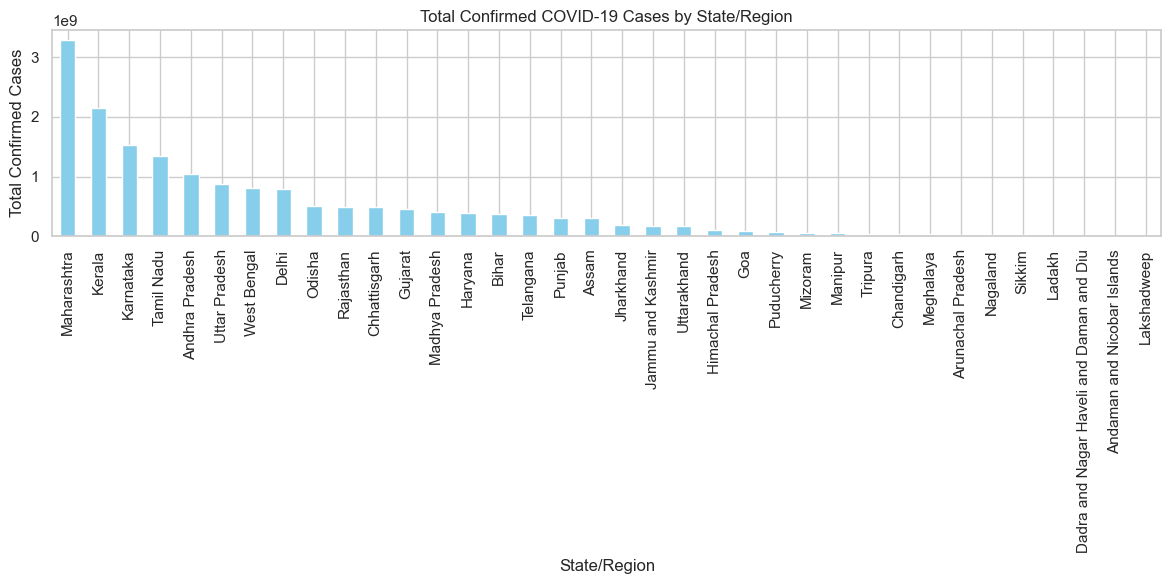

In [ ]:
# ----------------------------------------------------
# 2. Bar Plot: Total Confirmed Cases by Region (from covid_data)
# ----------------------------------------------------
total_confirmed_by_region = covid_data.groupby('region')['confirmed'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
total_confirmed_by_region.plot(kind='bar', color='skyblue')
plt.title('Total Confirmed COVID-19 Cases by Region')
plt.xlabel('Region')
plt.ylabel('Total Confirmed Cases')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

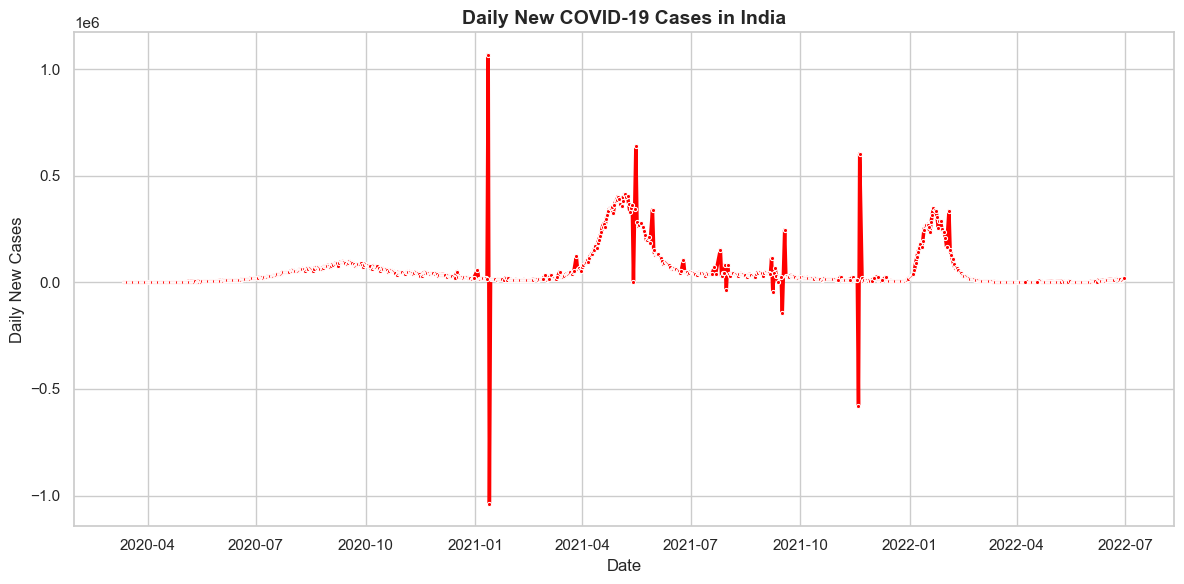

In [ ]:
# ----------------------------------------------------
# 3. Line Chart: Daily New Cases Over Time (aggregated)
# ----------------------------------------------------
covid_data['date'] = pd.to_datetime(covid_data['date'])
covid_data_sorted = covid_data.sort_values('date')

daily_cases = covid_data_sorted.groupby('date')['confirmed'].sum().reset_index()
daily_cases['daily_new_cases'] = daily_cases['confirmed'].diff().fillna(0)

plt.figure(figsize=(12,6))
sns.lineplot(data=daily_cases, x='date', y='daily_new_cases', 
            color='red', linewidth=2.5, marker='o', markersize=3)
plt.title('Daily New COVID-19 Cases in India', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily New Cases', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

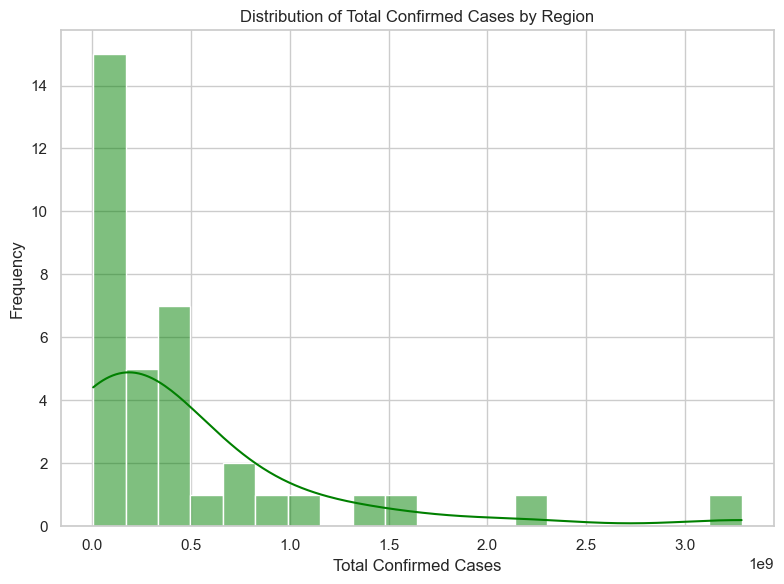

In [4]:
# ----------------------------------------------------
# 4. Histogram: Distribution of Total Confirmed Cases by Region
# ----------------------------------------------------
plt.figure(figsize=(8,6))
sns.histplot(total_confirmed_by_region, bins=20, color='green', kde=True)
plt.title('Distribution of Total Confirmed Cases by Region')
plt.xlabel('Total Confirmed Cases')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

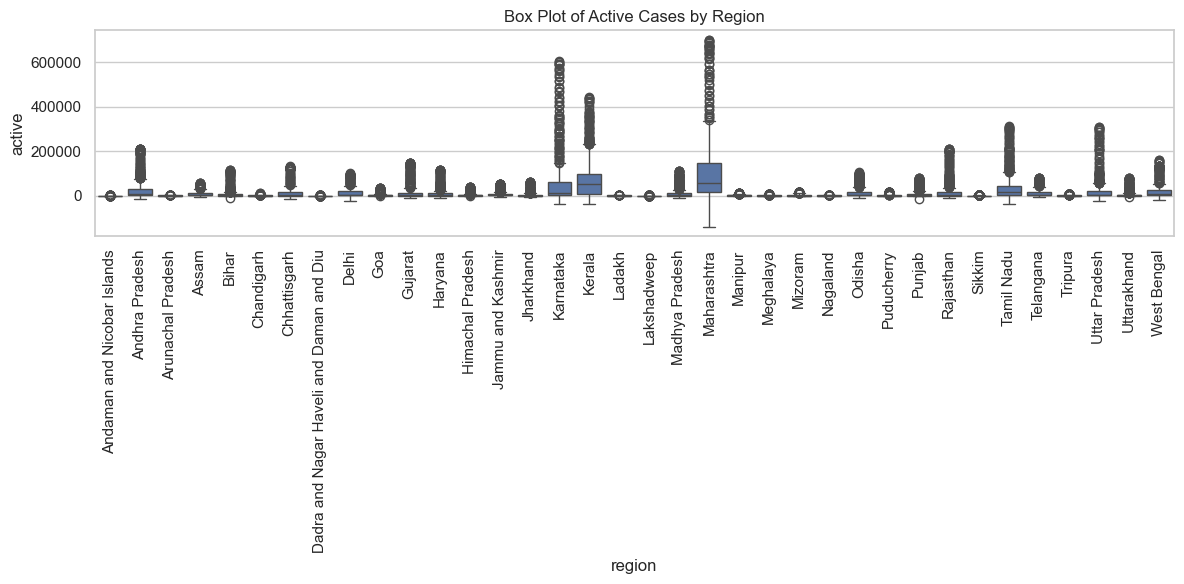

In [5]:
# ----------------------------------------------------
# 5. Box Plot: Active Cases by Region (from covid_data)
# ----------------------------------------------------
plt.figure(figsize=(12,6))
sns.boxplot(x='region', y='active', data=covid_data)
plt.title('Box Plot of Active Cases by Region')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [10]:
# ----------------------------------------------------
# 6. Pie Chart: Proportion of Total Confirmed Cases by Region
# ----------------------------------------------------
plt.figure(figsize=(8,8))
plt.pie(total_confirmed_by_region,
        labels=total_confirmed_by_region.index,
        autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Total Confirmed Cases by Region')
plt.tight_layout()
plt.show()

NameError: name 'total_confirmed_by_region' is not defined

<Figure size 800x800 with 0 Axes>

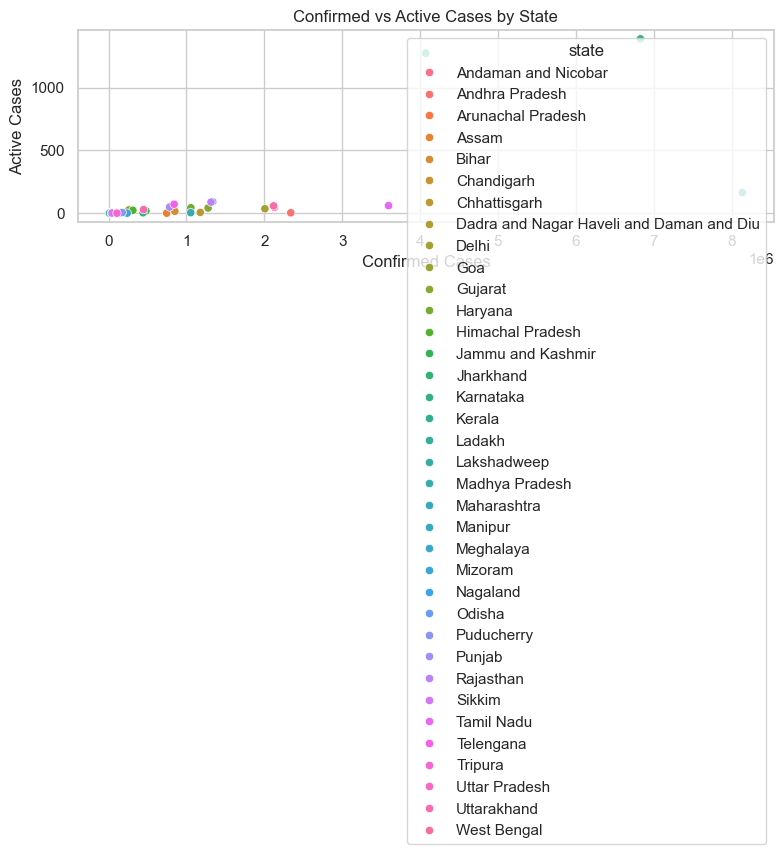

In [7]:
# ----------------------------------------------------
# 7. Scatter Plot: Confirmed vs Active Cases (from covid.csv)
# ----------------------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x='confirmed', y='active', hue='state', data=covid)
plt.title('Confirmed vs Active Cases by State')
plt.xlabel('Confirmed Cases')
plt.ylabel('Active Cases')
plt.tight_layout()
plt.show()

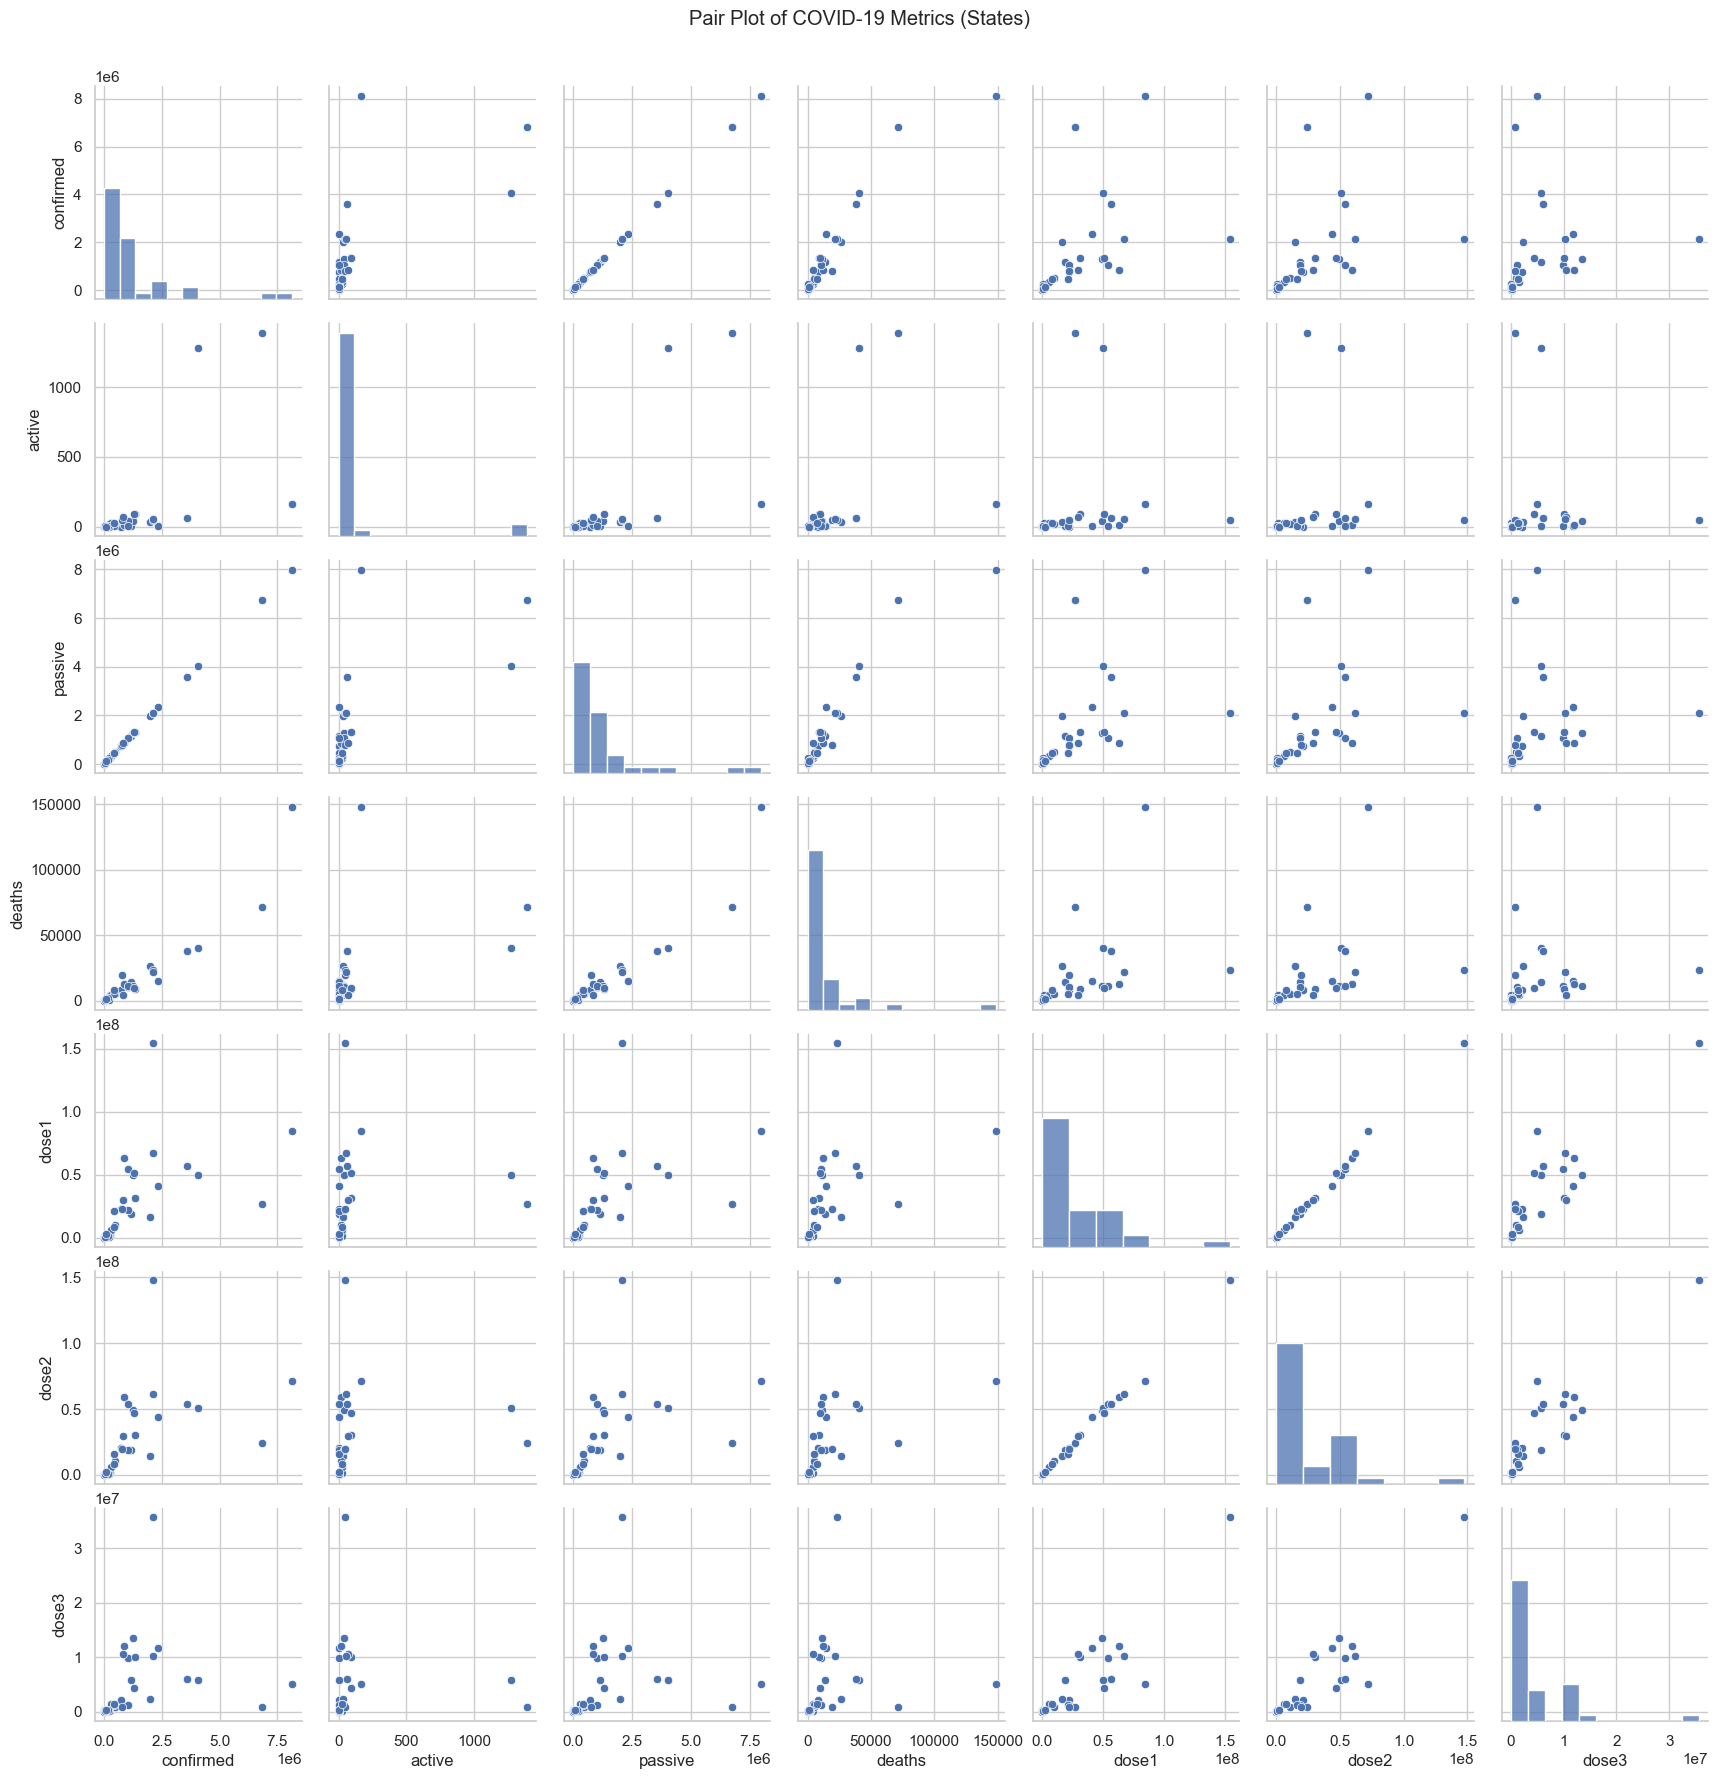

In [8]:
# ----------------------------------------------------
# 8. Pair Plot (from covid.csv)
# ----------------------------------------------------
# Pick relevant numeric columns for pairplot
numeric_cols = ['confirmed', 'active', 'passive', 'deaths', 'dose1', 'dose2', 'dose3']
sns.pairplot(covid[numeric_cols])
plt.suptitle('Pair Plot of COVID-19 Metrics (States)', y=1.02)
plt.show()